Exploratory Analysis of Bank Customer Churn

In [4]:
# Import required libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the customer churn dataset into a DataFrame
df=pd.read_csv("Customer-Churn-Records.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [6]:
# Display the number of rows and columns in the dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (10000, 18)


In [7]:
# Preview the first 5 records
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [8]:
# Preview the last 10 records
df.tail(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9990,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0,0,3,GOLD,791
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1,1,3,GOLD,369
9992,9993,15657105,Chukwualuka,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0,0,5,SILVER,560
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0,0,5,DIAMOND,715
9994,9995,15719294,Wood,800,France,Female,29,2,0.00,2,0,0,167773.55,0,0,4,PLATINUM,311
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


In [9]:
# Display dataset information such as data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [10]:
# Generate descriptive statistics for numerical and categorical columns
df.describe(include="all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DIAMOND,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,NaN,606.515100
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,NaN,225.924839
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,NaN,119.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,NaN,410.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,NaN,605.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,NaN,801.000000


In [11]:
# Check for missing values in each column
missing=df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [12]:
# Count customers with and without credit cards
df["HasCrCard"].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [13]:
# Count active and inactive members
df["IsActiveMember"].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [14]:
# Count churned and retained customers
df["Exited"].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [15]:
# Count customers based on number of products
df["NumOfProducts"].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [16]:
# Count customer complaints
df["Complain"].value_counts()

Complain
0    7956
1    2044
Name: count, dtype: int64

In [17]:
# Count satisfaction score distribution
df["Satisfaction Score"].value_counts()

Satisfaction Score
3    2042
2    2014
4    2008
5    2004
1    1932
Name: count, dtype: int64

In [18]:
# Count different card types
df["Card Type"].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

In [19]:
# Count tenure distribution
df["Tenure"].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [20]:
# Count gender distribution
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [21]:
# Count customer distribution by geography
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

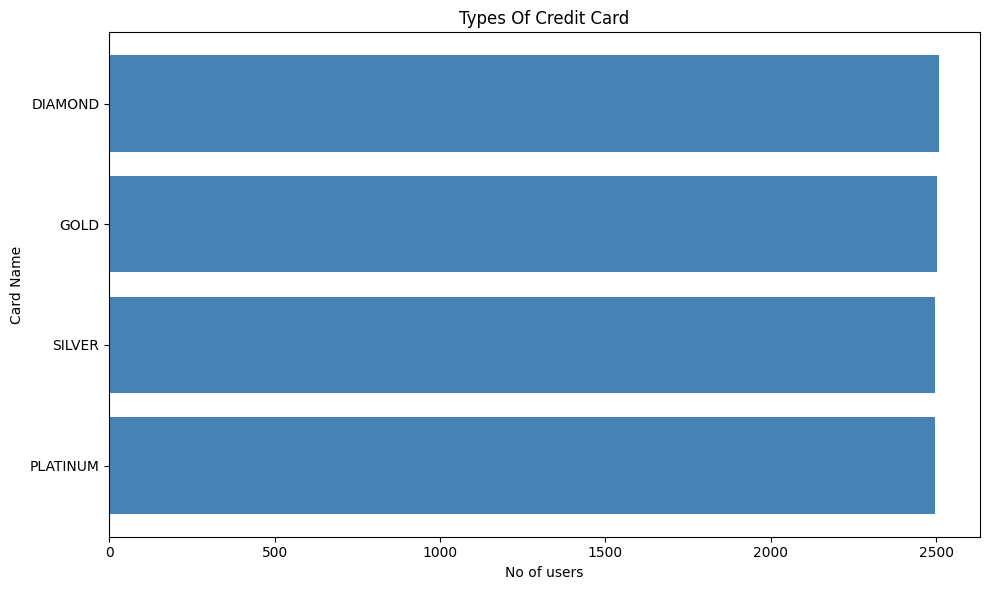

In [22]:
# Visualize the distribution of card types
card_type = df["Card Type"].value_counts()

plt.figure(figsize=(10,6))

plt.barh(
    card_type.index[::-1],
    card_type.values[::-1],
    color="steelblue"
)

plt.title("Types Of Credit Card")
plt.xlabel("No of users")
plt.ylabel("Card Name")

plt.tight_layout()
plt.show()

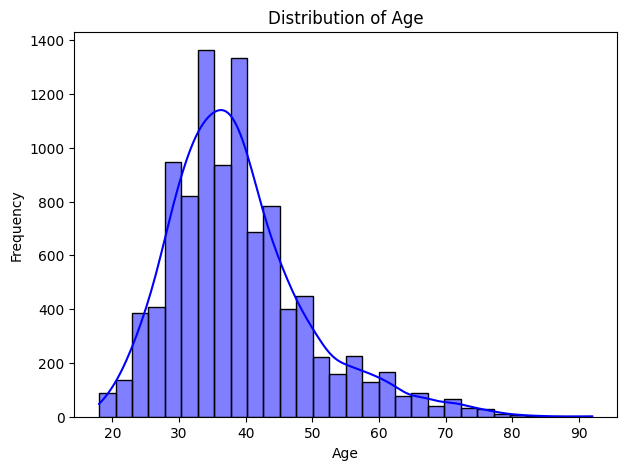

In [23]:
# Plot the age distribution of customers
plt.figure(figsize=(7,5))

sns.histplot(df["Age"], bins=30, kde=True, color="blue")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

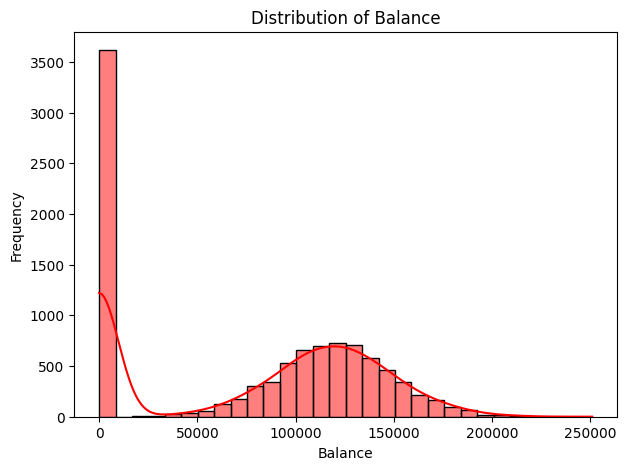

In [24]:
# Plot the balance distribution
plt.figure(figsize=(7,5))

sns.histplot(df["Balance"], bins=30, kde=True, color="red")

plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

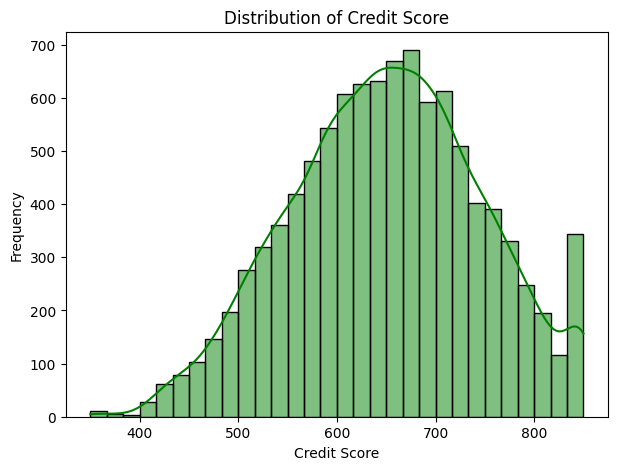

In [25]:
# Plot the credit score distribution
plt.figure(figsize=(7,5))

sns.histplot(df["CreditScore"], bins=30, kde=True, color="green")

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

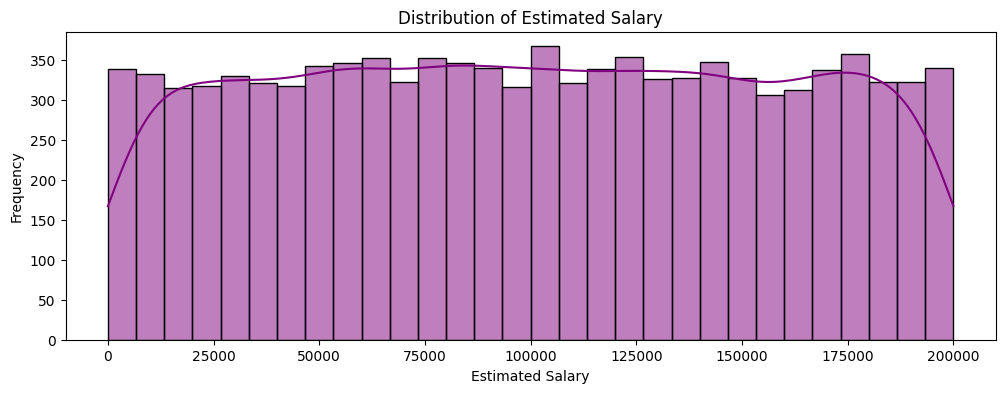

In [26]:
# Plot the estimated salary distribution
plt.figure(figsize=(12,4))

sns.histplot(df["EstimatedSalary"], bins=30, kde=True, color="purple")

plt.title("Distribution of Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.show()

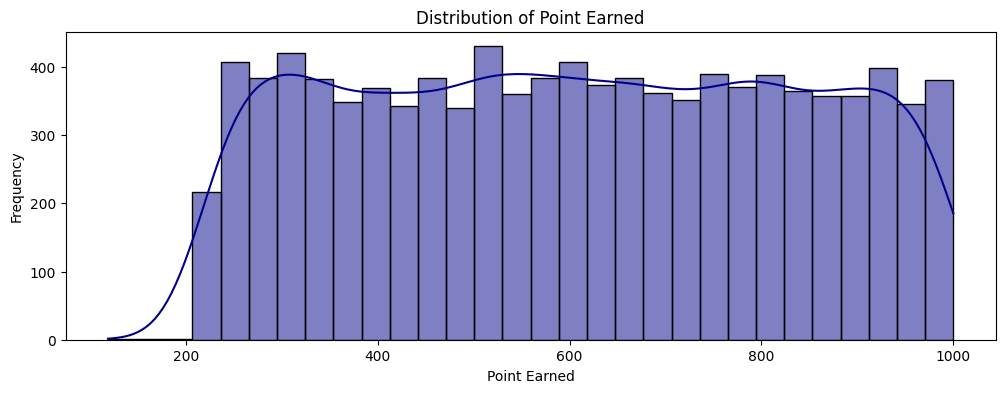

In [27]:
# Plot the points earned distribution
plt.figure(figsize=(12,4))

sns.histplot(df["Point Earned"], bins=30, kde=True, color="darkblue")

plt.title("Distribution of Point Earned")
plt.xlabel("Point Earned")
plt.ylabel("Frequency")
plt.show()

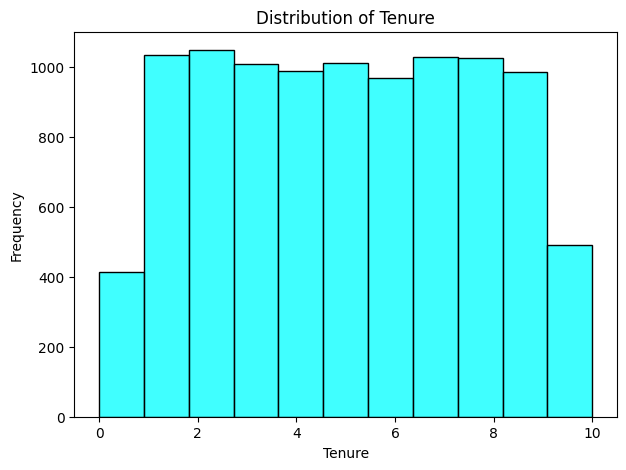

In [28]:
# Plot the tenure distribution
plt.figure(figsize=(7,5))

sns.histplot(df["Tenure"], bins=11, kde=False, color="cyan")

plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

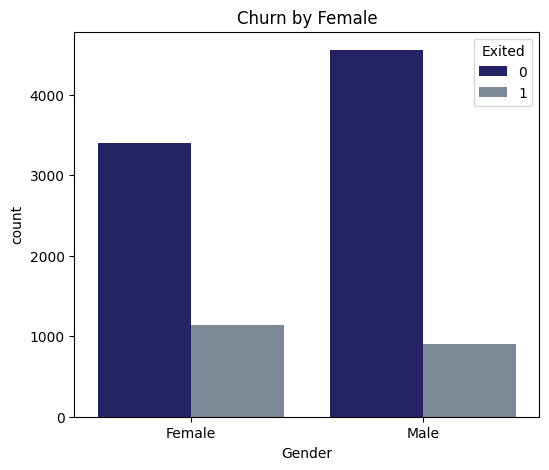

In [29]:
# Compare churn status by gender
plt.figure(figsize=(6,5))

sns.countplot(
    x="Gender",
    hue="Exited",
    data=df,
    palette=["midnightblue","lightslategray"]
)
plt.title("Churn by Female")
plt.show()

/var/folders/fz/fwg1d1fd3fgbnld77grjg53h0000gp/T/ipykernel_1163/2890161651.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(


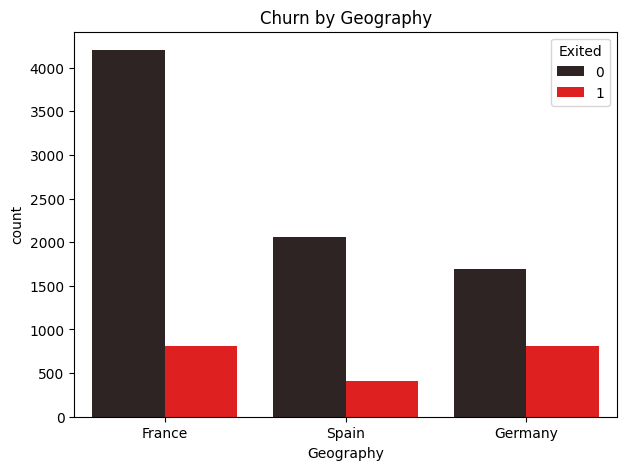

In [30]:
# Compare churn status by geography
plt.figure(figsize=(7,5))

sns.countplot(
    x="Geography",
    hue="Exited",
    data=df,
    color="red"
)
plt.title("Churn by Geography")
plt.show()

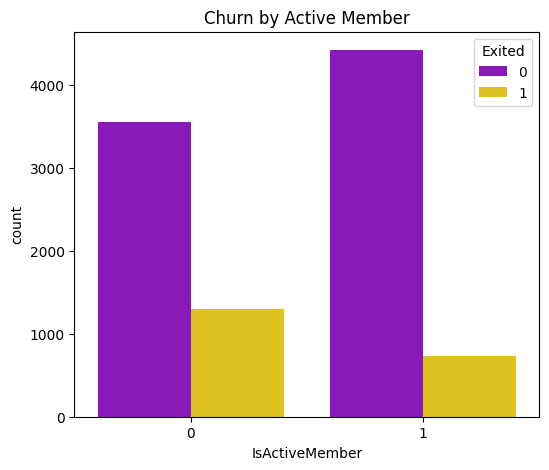

In [31]:
# Compare churn status by active membership
plt.figure(figsize=(6,5))

sns.countplot(
    x="IsActiveMember",
    hue="Exited",
    data=df,
    palette=["darkviolet","gold"]
)
plt.title("Churn by Active Member")
plt.show()

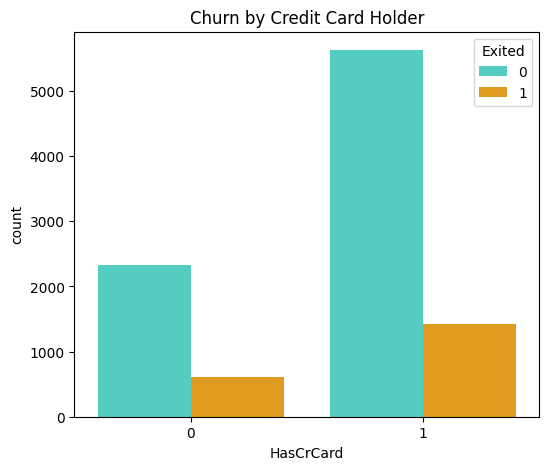

In [32]:
# Compare churn status by credit card ownership
plt.figure(figsize=(6,5))

sns.countplot(
    x="HasCrCard",
    hue="Exited",
    data=df,
    palette=["turquoise","orange"]
)
plt.title("Churn by Credit Card Holder")
plt.show()

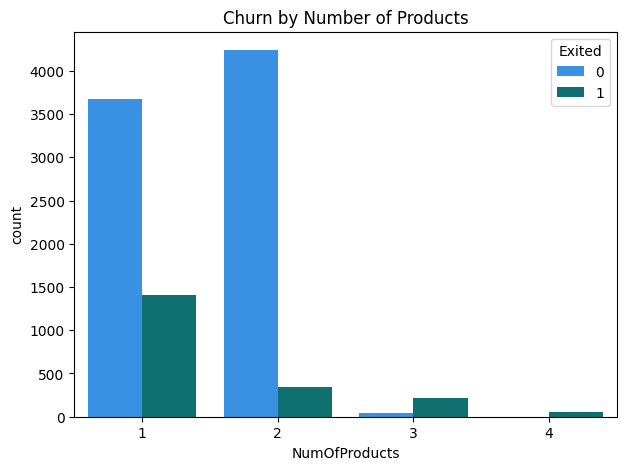

In [33]:
# Compare churn status by number of products
plt.figure(figsize=(7,5))

sns.countplot(
    x="NumOfProducts",
    hue="Exited",
    data=df,
    palette=["dodgerblue","teal"]
)
plt.title("Churn by Number of Products")
plt.show()

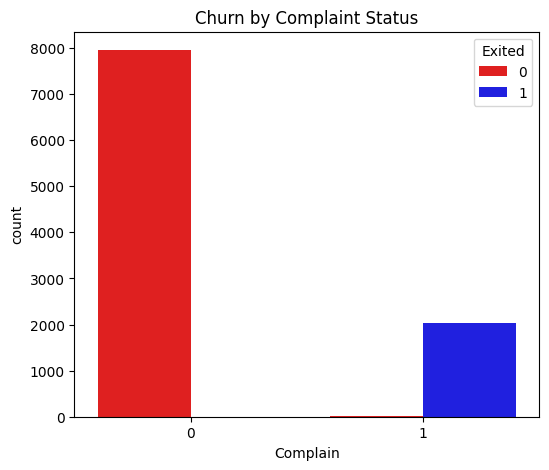

In [34]:
# Compare churn status by complaints
plt.figure(figsize=(6,5))

sns.countplot(
    x="Complain",
    hue="Exited",
    data=df,
    palette=["red","blue"]
)
plt.title("Churn by Complaint Status")
plt.show()

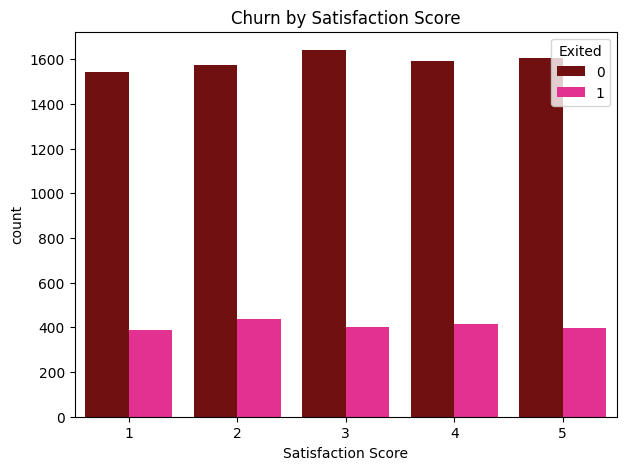

In [35]:
# Compare churn status by satisfaction score
plt.figure(figsize=(7,5))

sns.countplot(
    x="Satisfaction Score",
    hue="Exited",
    data=df,
    palette=["maroon","deeppink"]
)
plt.title("Churn by Satisfaction Score")
plt.show()

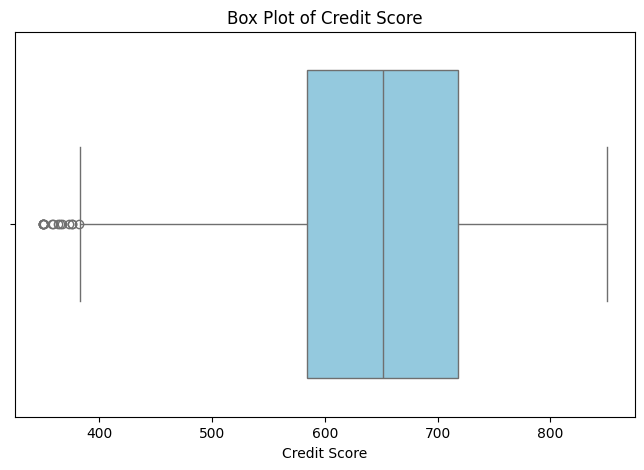

In [ ]:
# Creating a box plot to identify outliers in customer credit scores
plt.figure(figsize=(8,5))

sns.boxplot(x=df["CreditScore"], color="skyblue")

plt.title("Box Plot of Credit Score")
plt.xlabel("Credit Score")
plt.show()

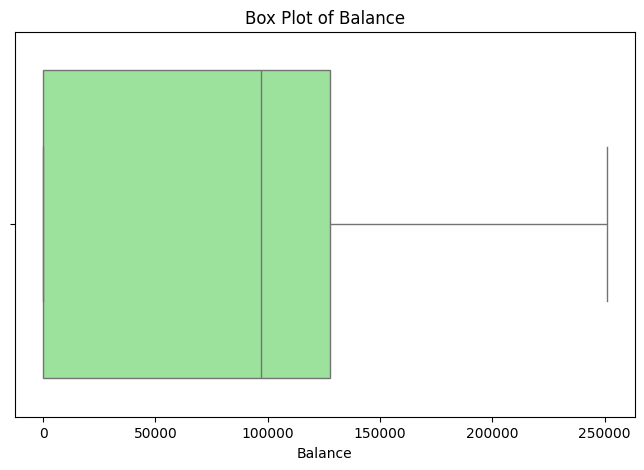

In [ ]:
# Creating a box plot to identify outliers in customer account balances
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Balance"], color="lightgreen")

plt.title("Box Plot of Balance")
plt.xlabel("Balance")
plt.show()

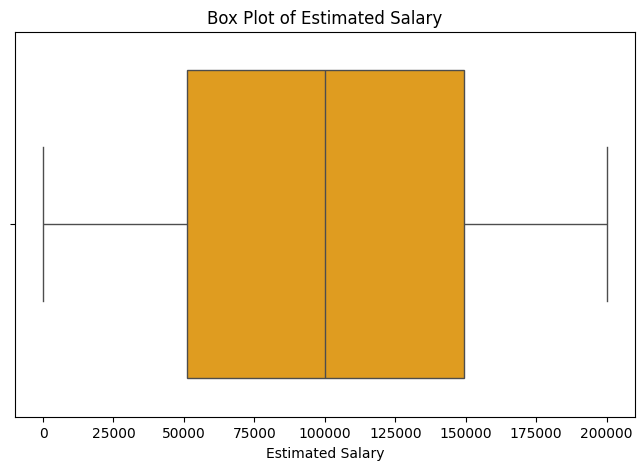

In [38]:
# Create a box plot to analyze the distribution of estimated salaries
plt.figure(figsize=(8,5))

sns.boxplot(x=df["EstimatedSalary"], color="orange")

plt.title("Box Plot of Estimated Salary")
plt.xlabel("Estimated Salary")
plt.show()

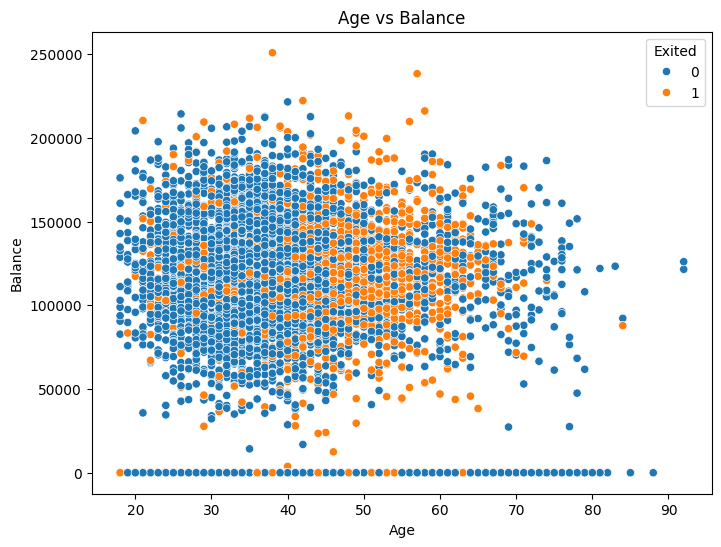

In [ ]:
# Creating a scatter plot to visualize the relationship between age, balance, and churn status
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="Balance",
    hue="Exited",
    data=df
)

plt.title("Age vs Balance")
plt.show()

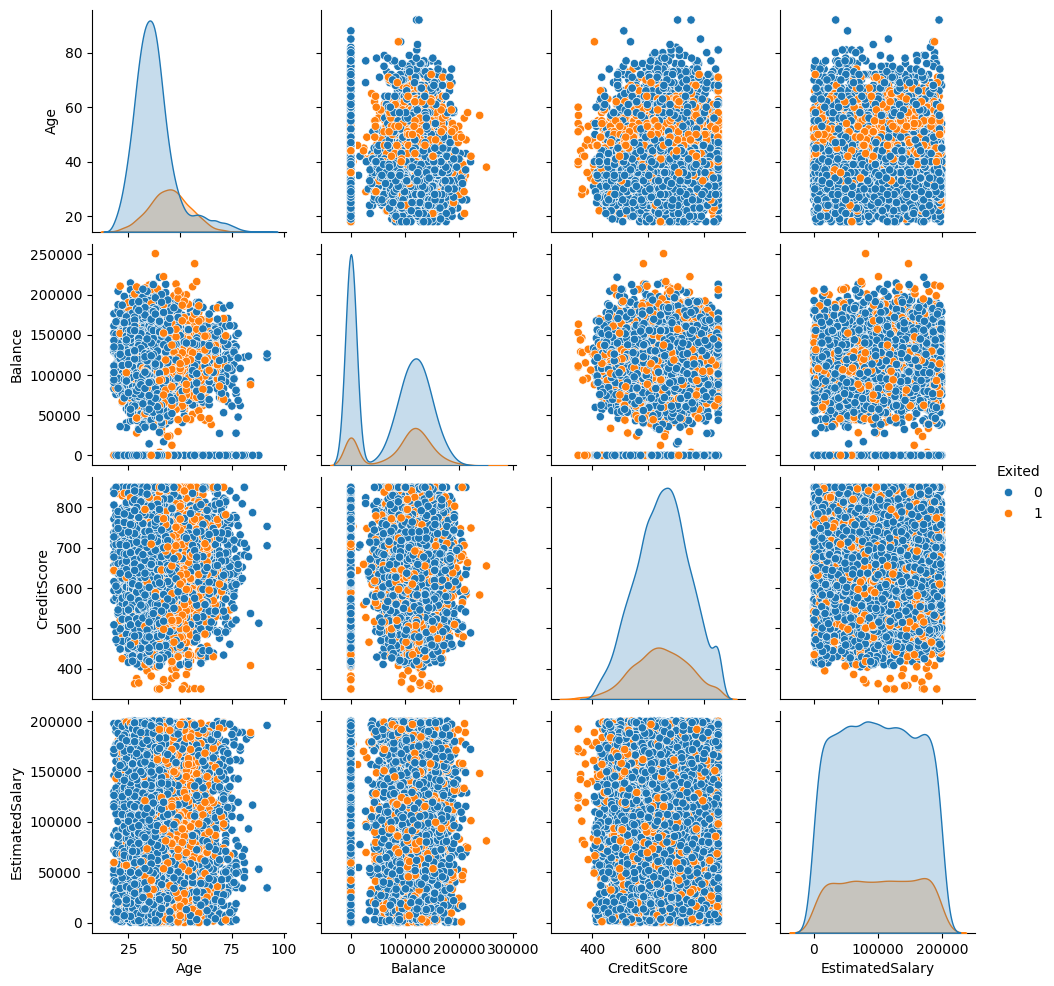

In [ ]:
# pair plot to examine relationships among key numerical features
sns.pairplot(
    df[["Age","Balance","CreditScore","EstimatedSalary","Exited"]],
    hue="Exited"
)

plt.show()

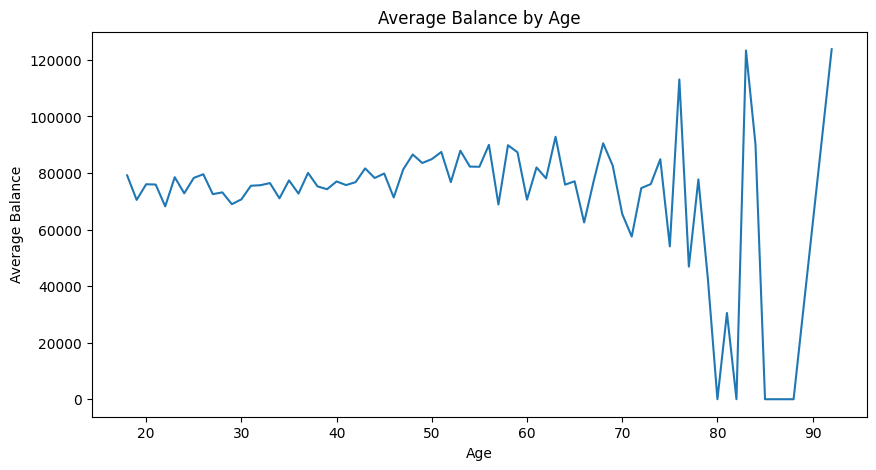

In [41]:
# Calculate and plot the average account balance for each age group
age_balance = df.groupby("Age")["Balance"].mean()

plt.figure(figsize=(10,5))

plt.plot(age_balance.index, age_balance.values)

plt.title("Average Balance by Age")
plt.xlabel("Age")
plt.ylabel("Average Balance")

plt.show()

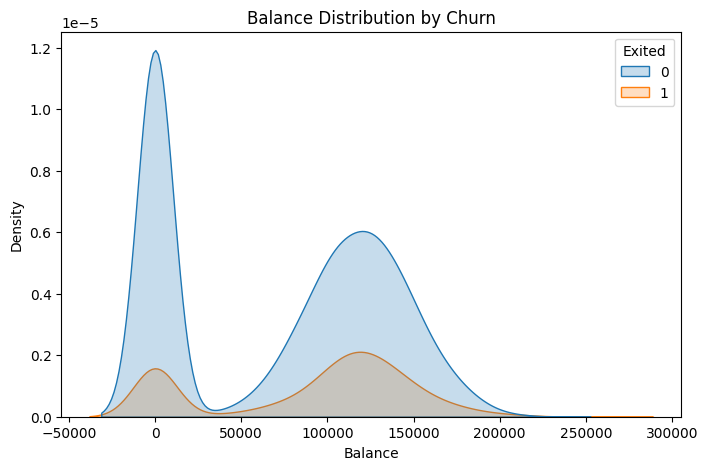

In [42]:
# Plot the density distribution of account balance based on churn status
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Balance",
    hue="Exited",
    fill=True
)

plt.title("Balance Distribution by Churn")
plt.show()

/var/folders/fz/fwg1d1fd3fgbnld77grjg53h0000gp/T/ipykernel_1163/3412208698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


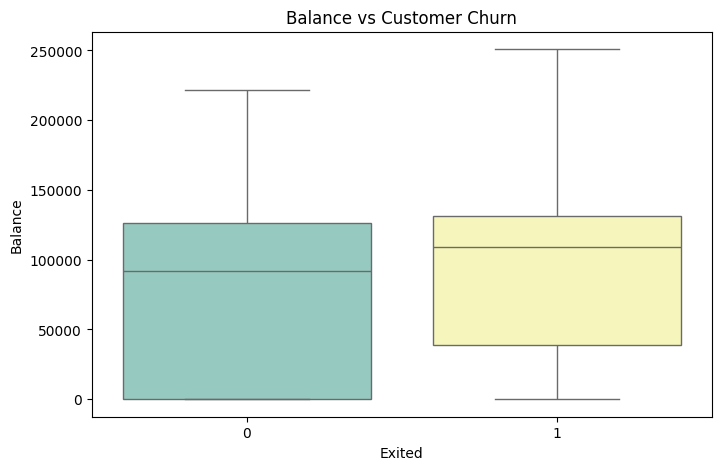

In [ ]:
# Comparing account balance distributions between retained and churned customers using a box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df,
    palette="Set3"
)

plt.title("Balance vs Customer Churn")
plt.show()

Conclusion:
This project analyzed customer churn using Python through data cleaning, exploratory data analysis,and visualizations.The analysis identified key factors influencing churn, such as age, account activity, product usage, geography, and customer satisfaction.These insights help businesses understand customer behavior,improve retention strategies,and make data-driven decisions.